In [6]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
masoudnickparvar_brain_tumor_mri_dataset_path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Data source import complete.


# 1. Import needed libraries

In [7]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
#---------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
#---------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#---------------------------------------
import warnings
warnings.filterwarnings("ignore")

# 2. Preprocessing

## 2.1 Load data

In [8]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [9]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [10]:
tr_df = train_df('/kaggle/input/brain-tumor-mri-dataset/Training')

In [11]:
tr_df

,Class Path,Class
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5595,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5596,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5597,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5598,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [12]:
ts_df = test_df('/kaggle/input/brain-tumor-mri-dataset/Testing')

In [13]:
ts_df

,Class Path,Class
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1595,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1596,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1597,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1598,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


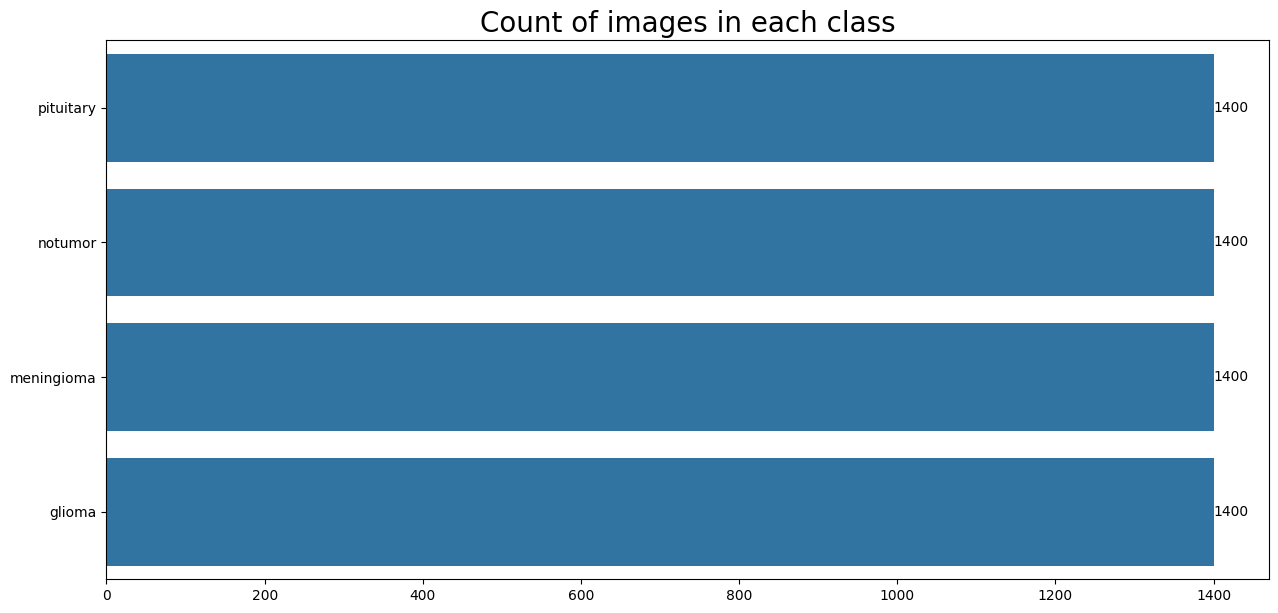

In [14]:
# Count of images in each class in train data
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

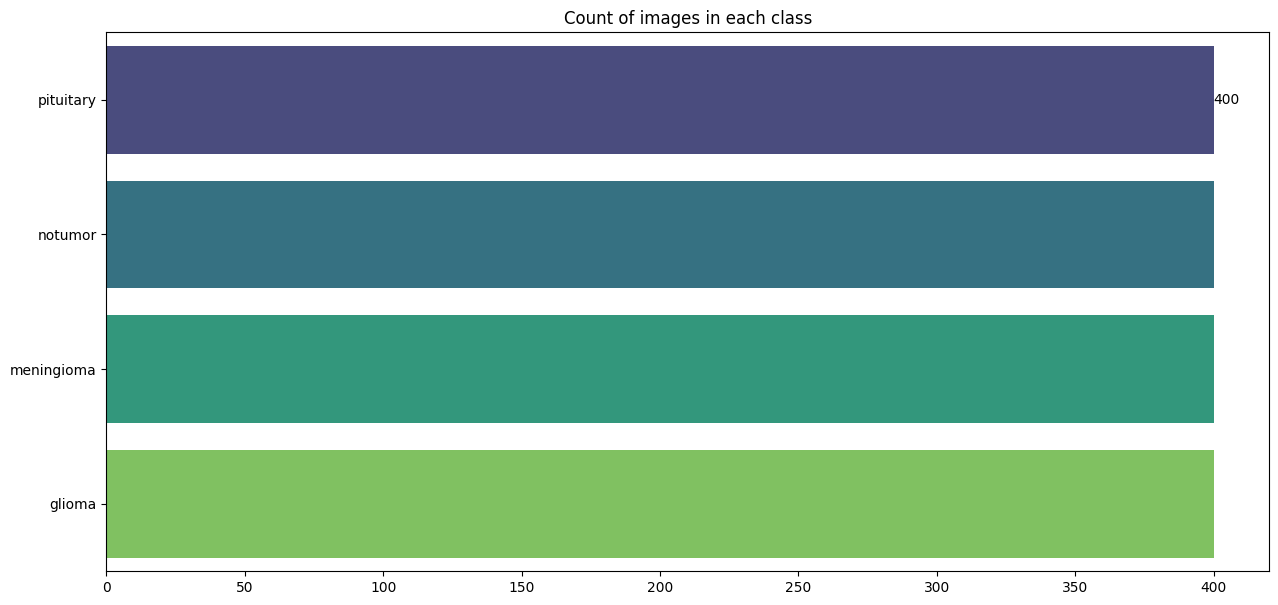

In [15]:
#Count each class in test data
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

## 2.2 Split data into train, test, valid

In [16]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [17]:
valid_df

,Class Path,Class
198,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
857,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
1098,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
1119,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma
508,/kaggle/input/brain-tumor-mri-dataset/Testing/...,notumor
...,...,...
1281,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
172,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
792,/kaggle/input/brain-tumor-mri-dataset/Testing/...,notumor
933,/kaggle/input/brain-tumor-mri-dataset/Testing/...,meningioma


## 2.3 Data preprocessing

In [18]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


## 2.4 Getting samples from data

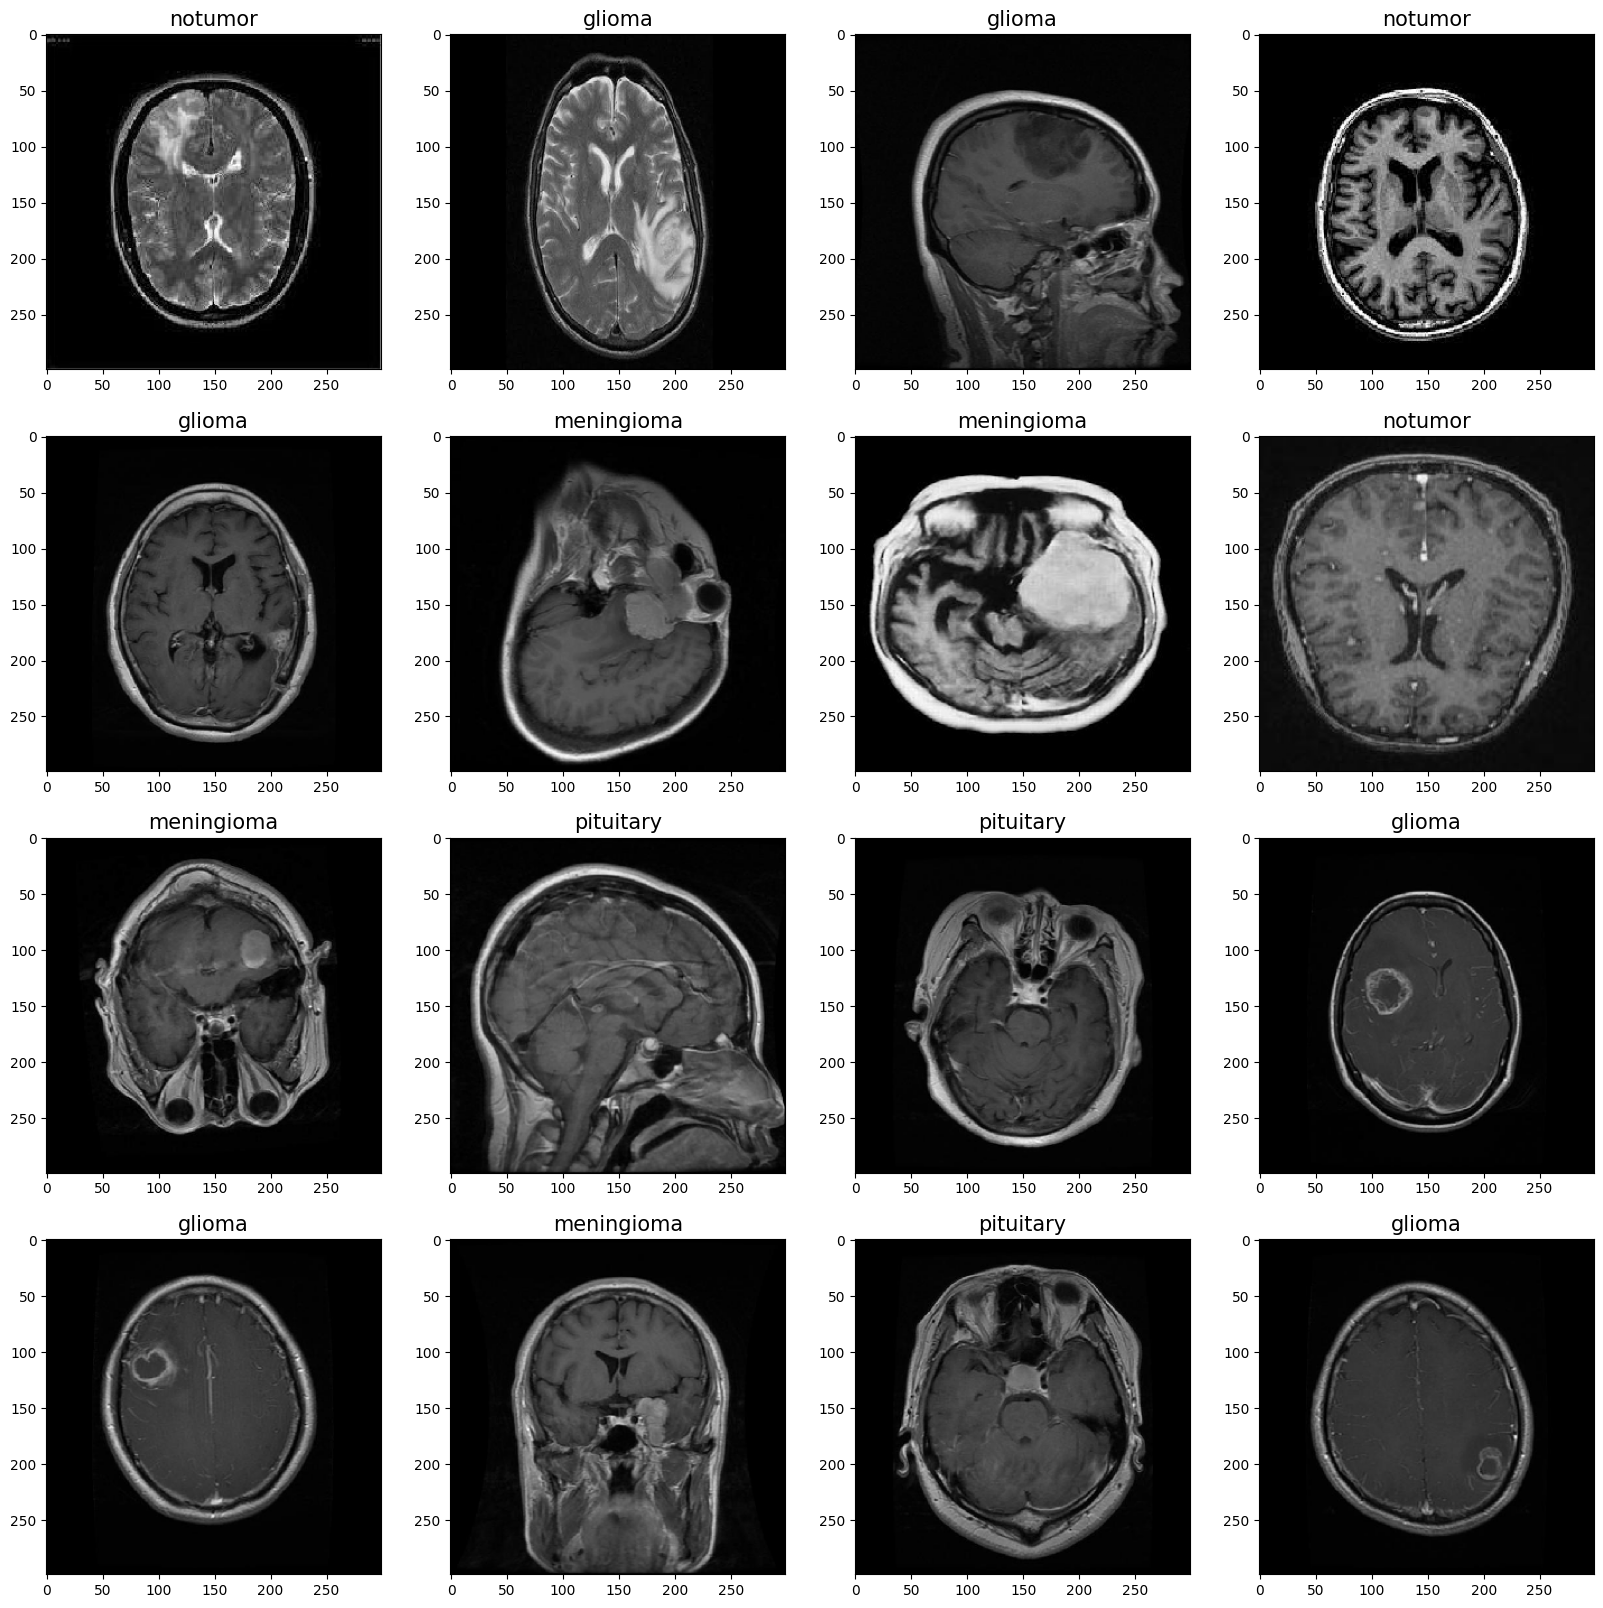

In [19]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

# 3. Building Deep Learning Model

In [20]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

#from tensorflow.keras.applications import VGG16  # For using VGG16 model
#IMAGE_SIZE = 299  # Image size (adjust based on your requirements)
#base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# for layer in base_model.layers:
#     layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

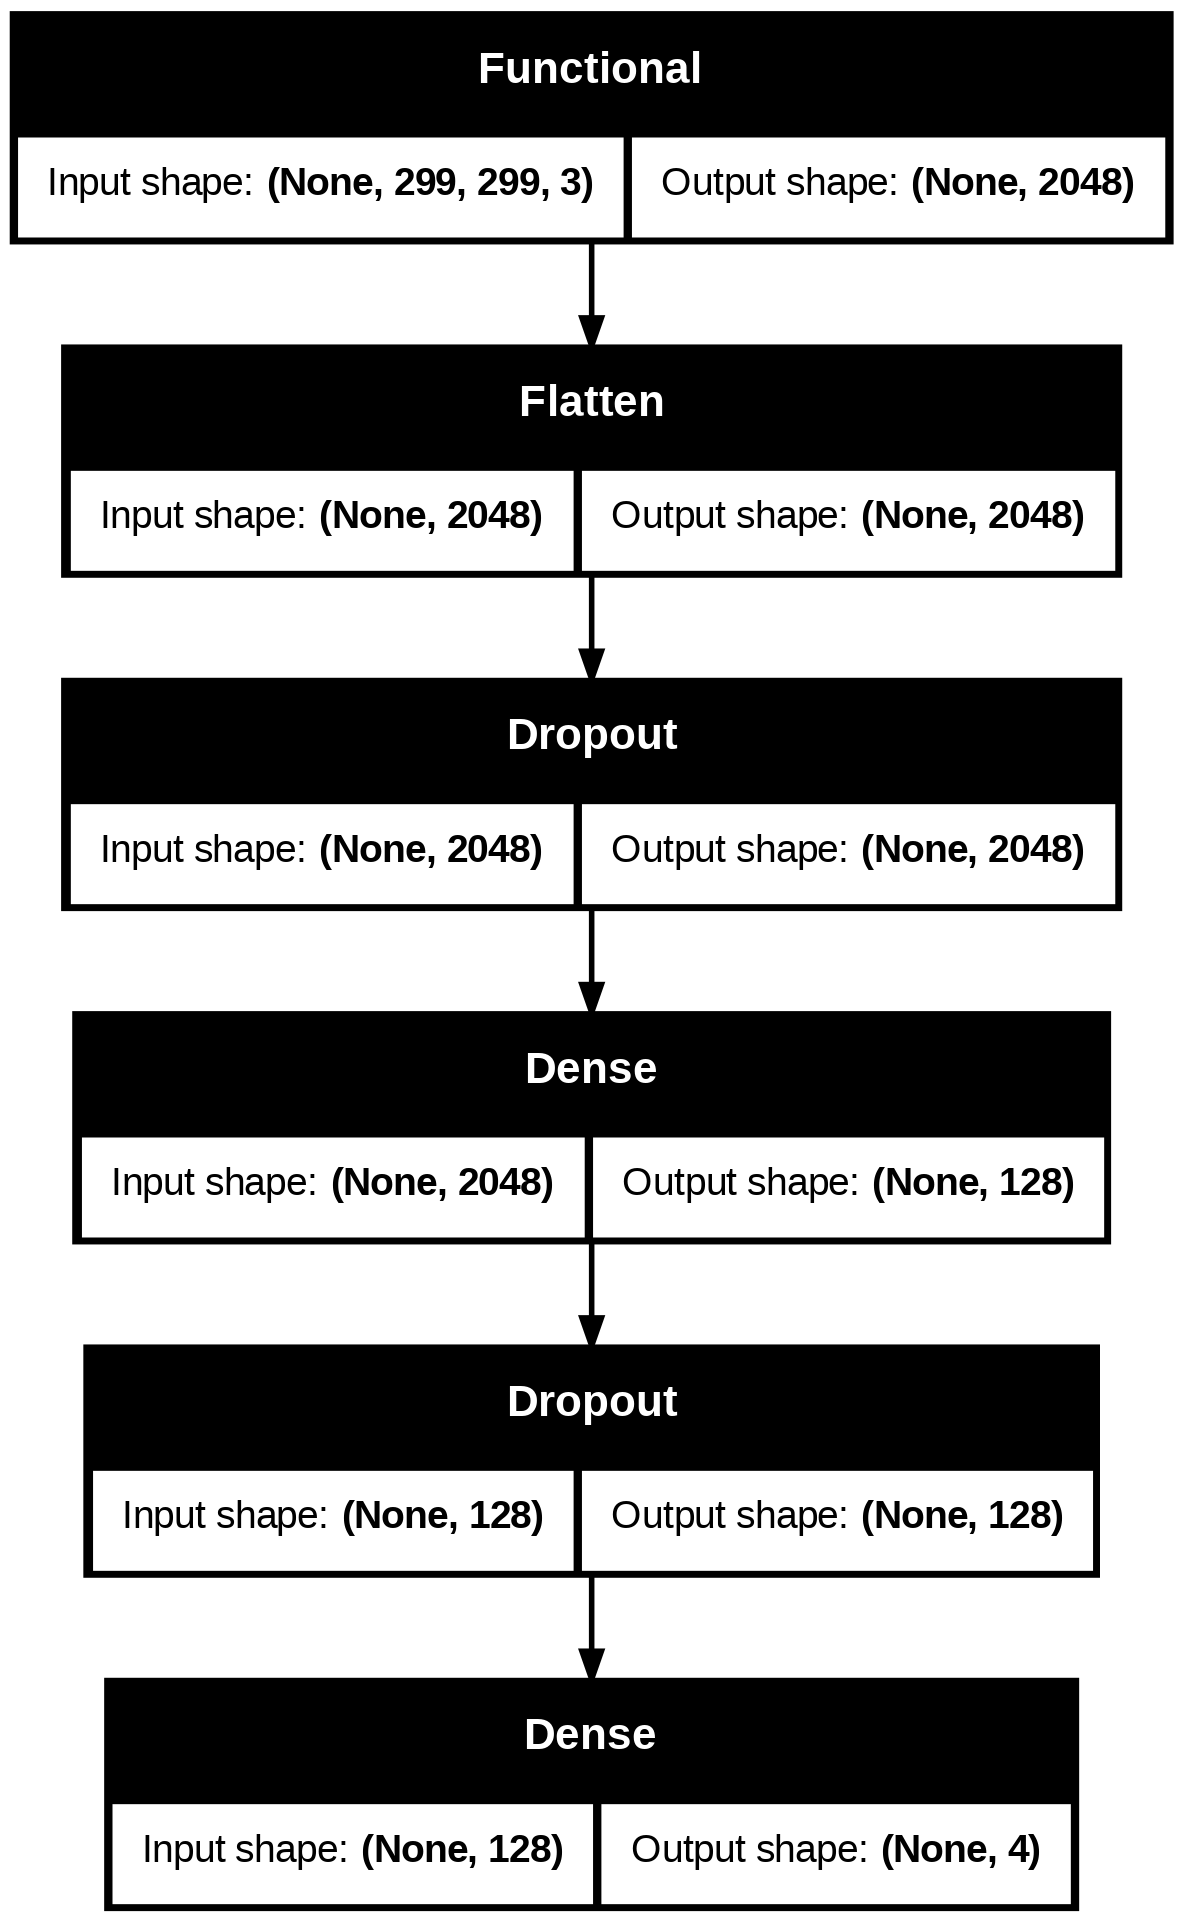

In [21]:
tf.keras.utils.plot_model(model, show_shapes=True)

# 4. Training

In [22]:
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 shuffle= False)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.8737 - loss: 0.3802 - precision_1: 0.9136 - recall_1: 0.8273 - val_accuracy: 0.7850 - val_loss: 0.7644 - val_precision_1: 0.7866 - val_recall_1: 0.7788
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 161s 919ms/step - accuracy: 0.9795 - loss: 0.0683 - precision_1: 0.9815 - recall_1: 0.9777 - val_accuracy: 0.9225 - val_loss: 0.4170 - val_precision_1: 0.9237 - val_recall_1: 0.9225
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 160s 914ms/step - accuracy: 0.9907 - loss: 0.0315 - precision_1: 0.9912 - recall_1: 0.9904 - val_accuracy: 0.9175 - val_loss: 0.3408 - val_precision_1: 0.9195 - val_recall_1: 0.9137
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 160s 915ms/step - accuracy: 0.9920 - loss: 0.0259 - precision_1: 0.9925 - recall_1: 0.9920 - val_accuracy: 0.9350 - val_loss: 0.4083 - val_precision_1: 0.9362 - val_recall_1: 0.9350
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 160s 916ms/step - accuracy: 0.9955 - loss: 0.0116 - precision_1: 0.9957 - r

### Re-running Model Training to define `hist`

It appears the `hist` variable, which holds the training history, was not defined or was lost from the kernel's memory. To proceed, the model training needs to be re-executed to re-create this variable. Please note that this process might take some time.

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall

img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

#from tensorflow.keras.applications import VGG16  # For using VGG16 model
#IMAGE_SIZE = 299  # Image size (adjust based on your requirements)
#base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# for layer in base_model.layers:
#     layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy',
                        Precision(),
                        Recall()])

model.summary()

hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 shuffle= False)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 238s 997ms/step - accuracy: 0.8704 - loss: 0.3718 - precision_2: 0.9142 - recall_2: 0.8277 - val_accuracy: 0.9112 - val_loss: 0.2701 - val_precision_2: 0.9167 - val_recall_2: 0.9075
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 161s 918ms/step - accuracy: 0.9807 - loss: 0.0674 - precision_2: 0.9830 - recall_2: 0.9784 - val_accuracy: 0.9488 - val_loss: 0.2042 - val_precision_2: 0.9510 - val_recall_2: 0.9463
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 160s 913ms/step - accuracy: 0.9893 - loss: 0.0345 - precision_2: 0.9900 - recall_2: 0.9884 - val_accuracy: 0.9137 - val_loss: 0.3817 - val_precision_2: 0.9191 - val_recall_2: 0.9087
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 160s 914ms/step - accuracy: 0.9950 - loss: 0.0167 - precision_2: 0.9952 - recall_2: 0.9946 - val_accuracy: 0.9413 - val_loss: 0.3913 - val_precision_2: 0.9411 - val_recall_2: 0.9388
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 160s 913ms/step - accuracy: 0.9980 - loss: 0.0098 - precision_2: 0.9980 

In [24]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision_2', 'recall_2', 'val_accuracy', 'val_loss', 'val_precision_2', 'val_recall_2'])

## 4.1 Visualize model performance

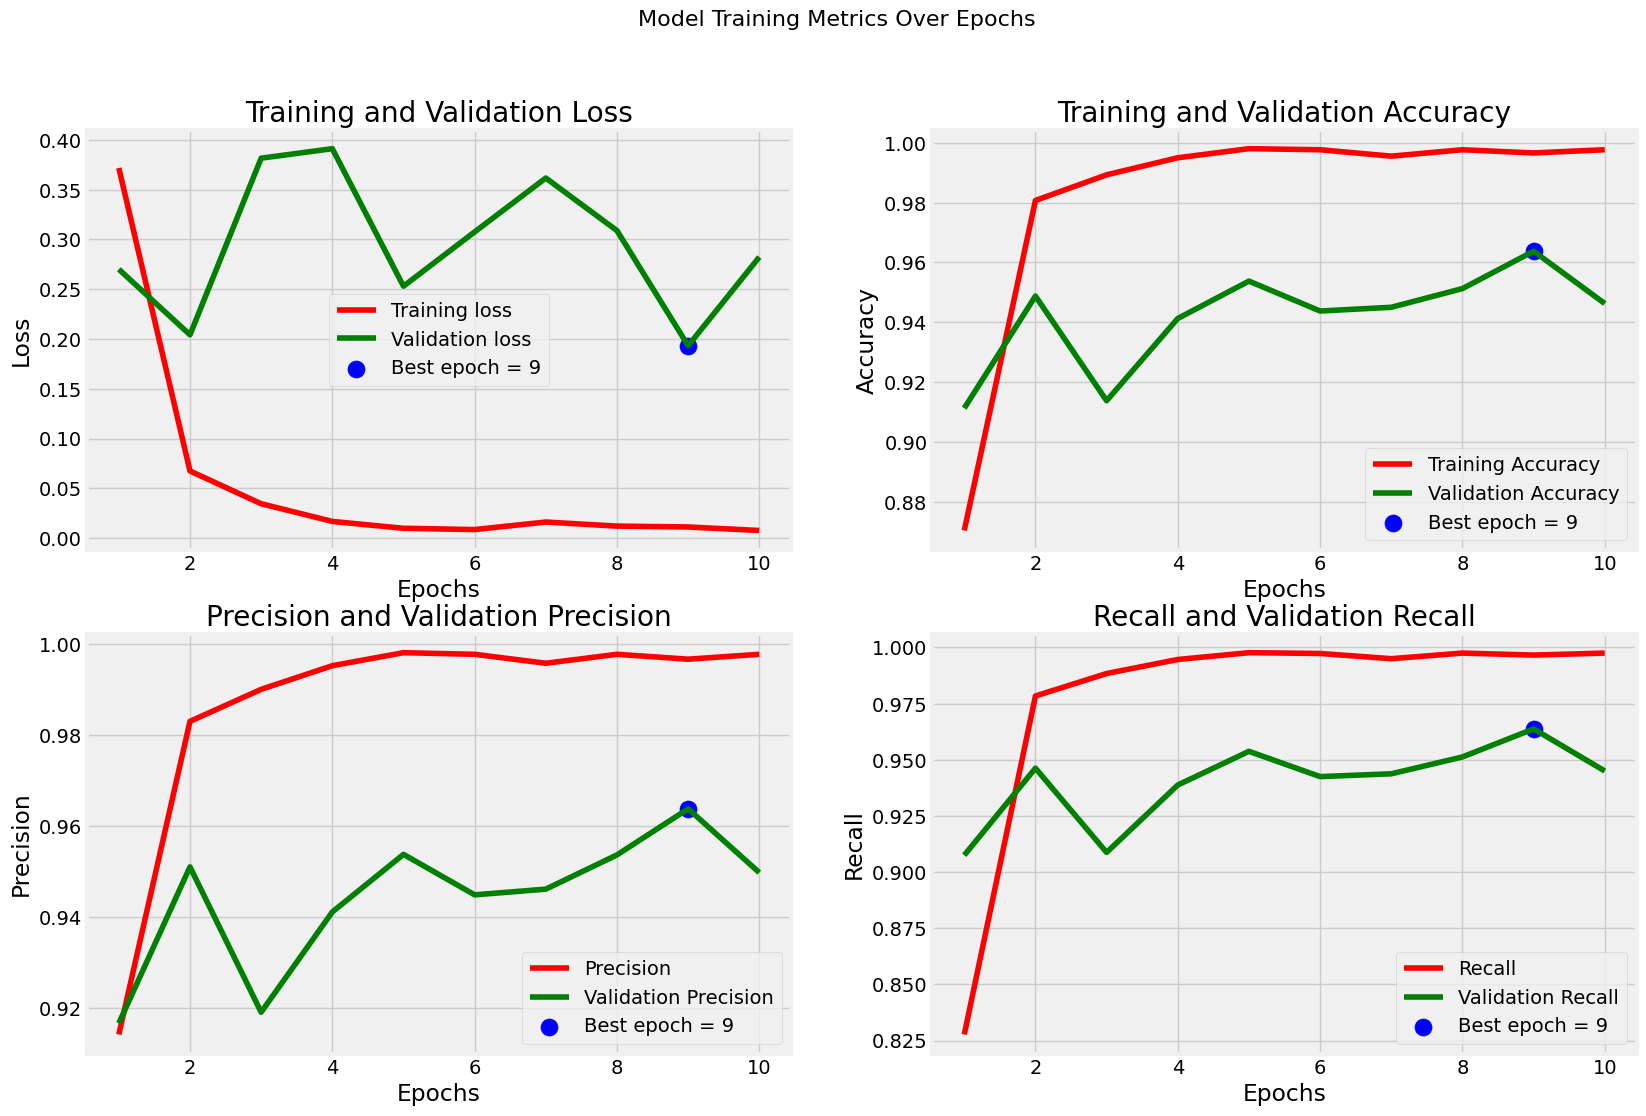

In [26]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision_2']
tr_recall = hist.history['recall_2']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision_2']
val_recall = hist.history['val_recall_2']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.show()

# 5. Testing and Evaluation

## 5.1 Evaluate

In [27]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")


175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 266ms/step - accuracy: 0.9973 - loss: 0.0098 - precision_2: 0.9973 - recall_2: 0.9973
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 246ms/step - accuracy: 0.9438 - loss: 0.2876 - precision_2: 0.9460 - recall_2: 0.9413
50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.9475 - loss: 0.3493 - precision_2: 0.9475 - recall_2: 0.9475
Train Loss: 0.0098
Train Accuracy: 99.73%
--------------------
Validation Loss: 0.2876
Validation Accuracy: 94.38%
--------------------
Test Loss: 0.3493
Test Accuracy: 94.75%


In [28]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step


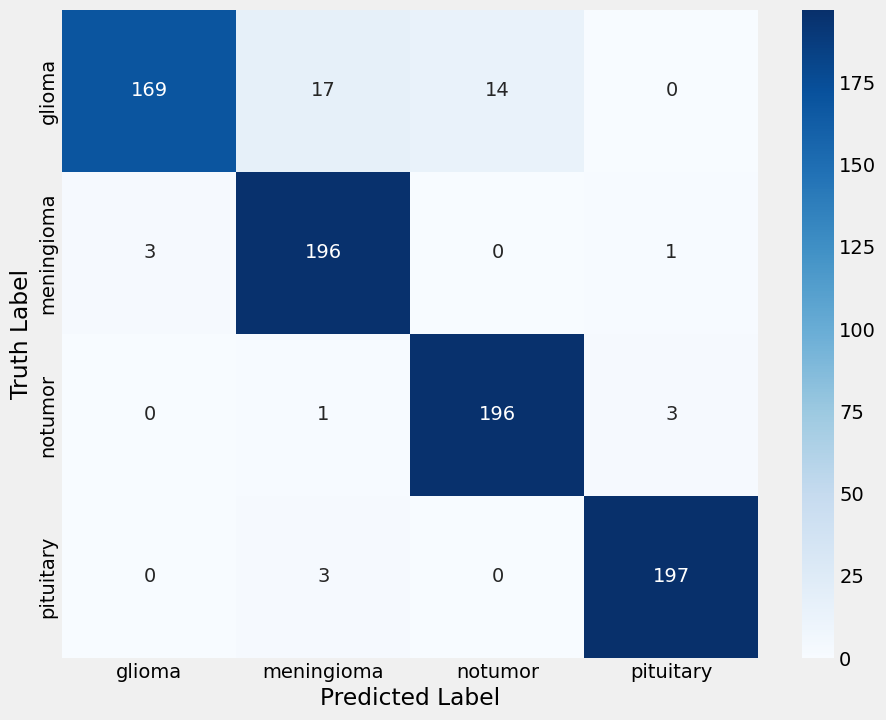

In [29]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [30]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       0.98      0.84      0.91       200
           1       0.90      0.98      0.94       200
           2       0.93      0.98      0.96       200
           3       0.98      0.98      0.98       200

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



## 5.2 Testing

In [31]:
def predict(img_path):
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((299, 299))
    # Ensure image is in RGB format before converting to numpy array
    img = np.asarray(resized_img.convert('RGB'))
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step


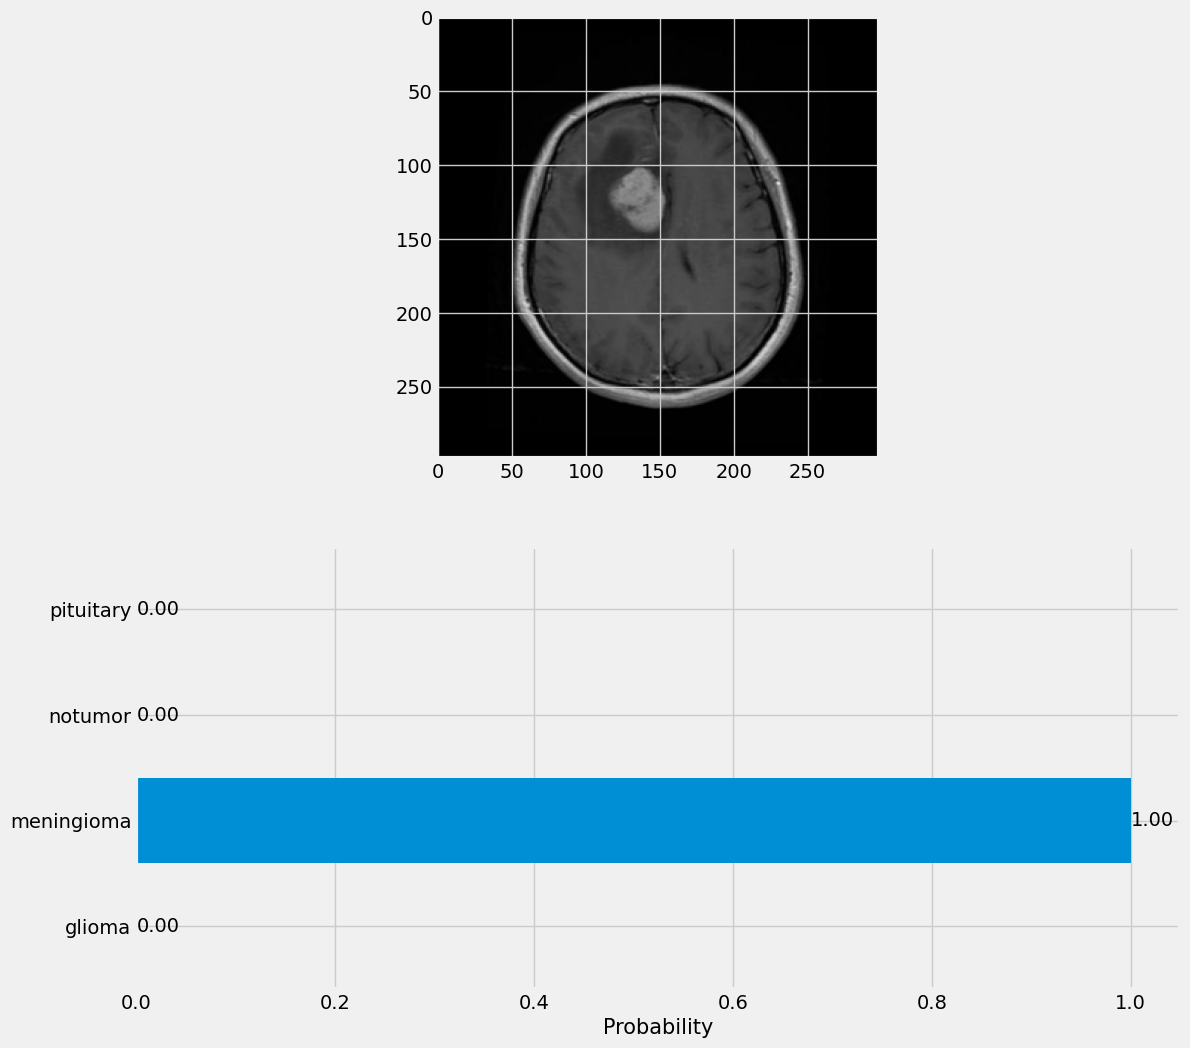

In [32]:
meningioma_image_path = ts_df[ts_df['Class'] == 'meningioma'].sample(1)['Class Path'].iloc[0]
predict(meningioma_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


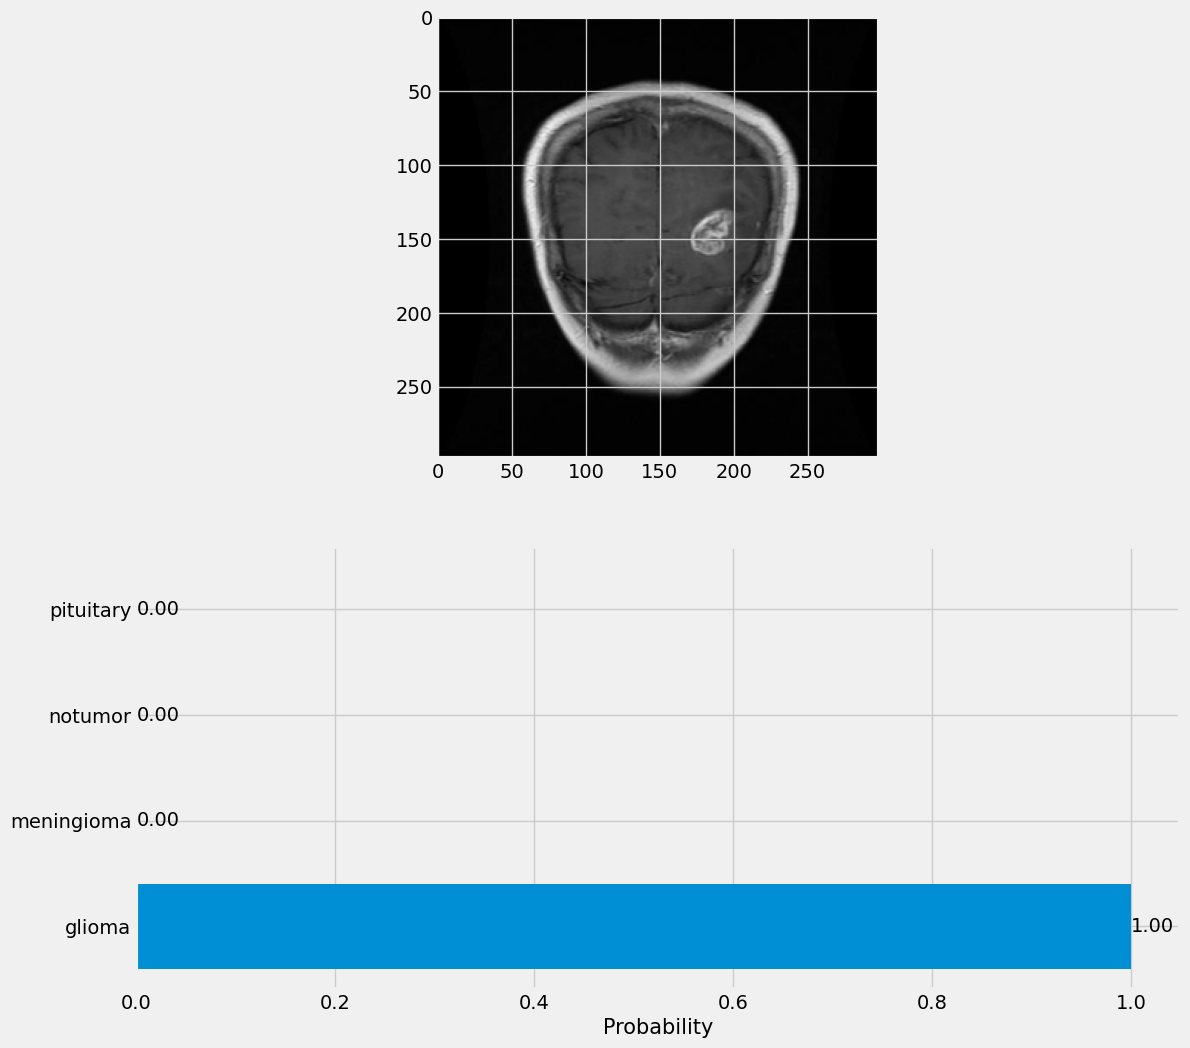

In [33]:
glioma_image_path = ts_df[ts_df['Class'] == 'glioma'].sample(1)['Class Path'].iloc[0]
predict(glioma_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


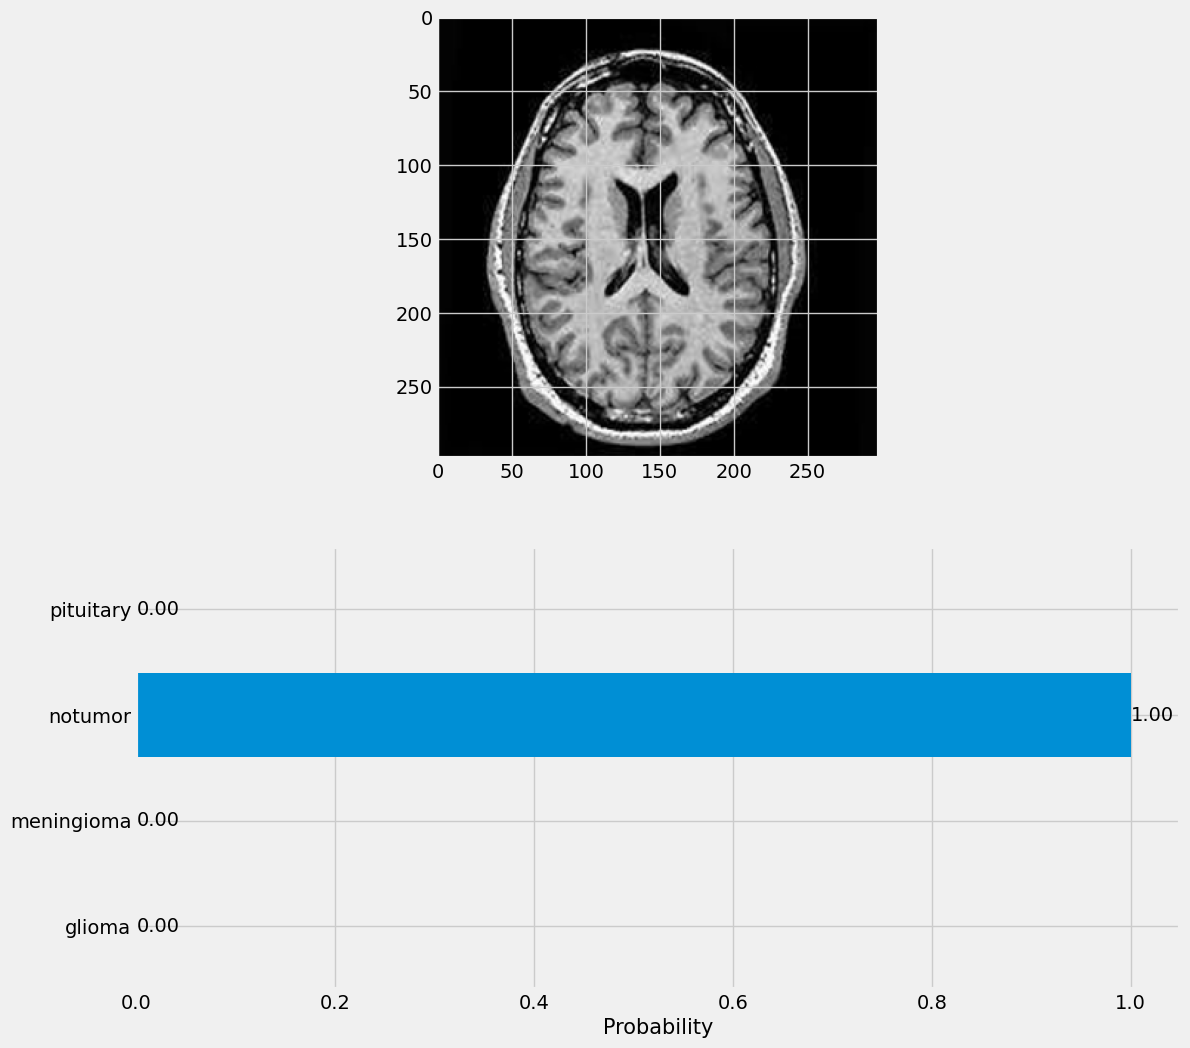

In [34]:
notumor_image_path = ts_df[ts_df['Class'] == 'notumor'].sample(1)['Class Path'].iloc[0]
predict(notumor_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


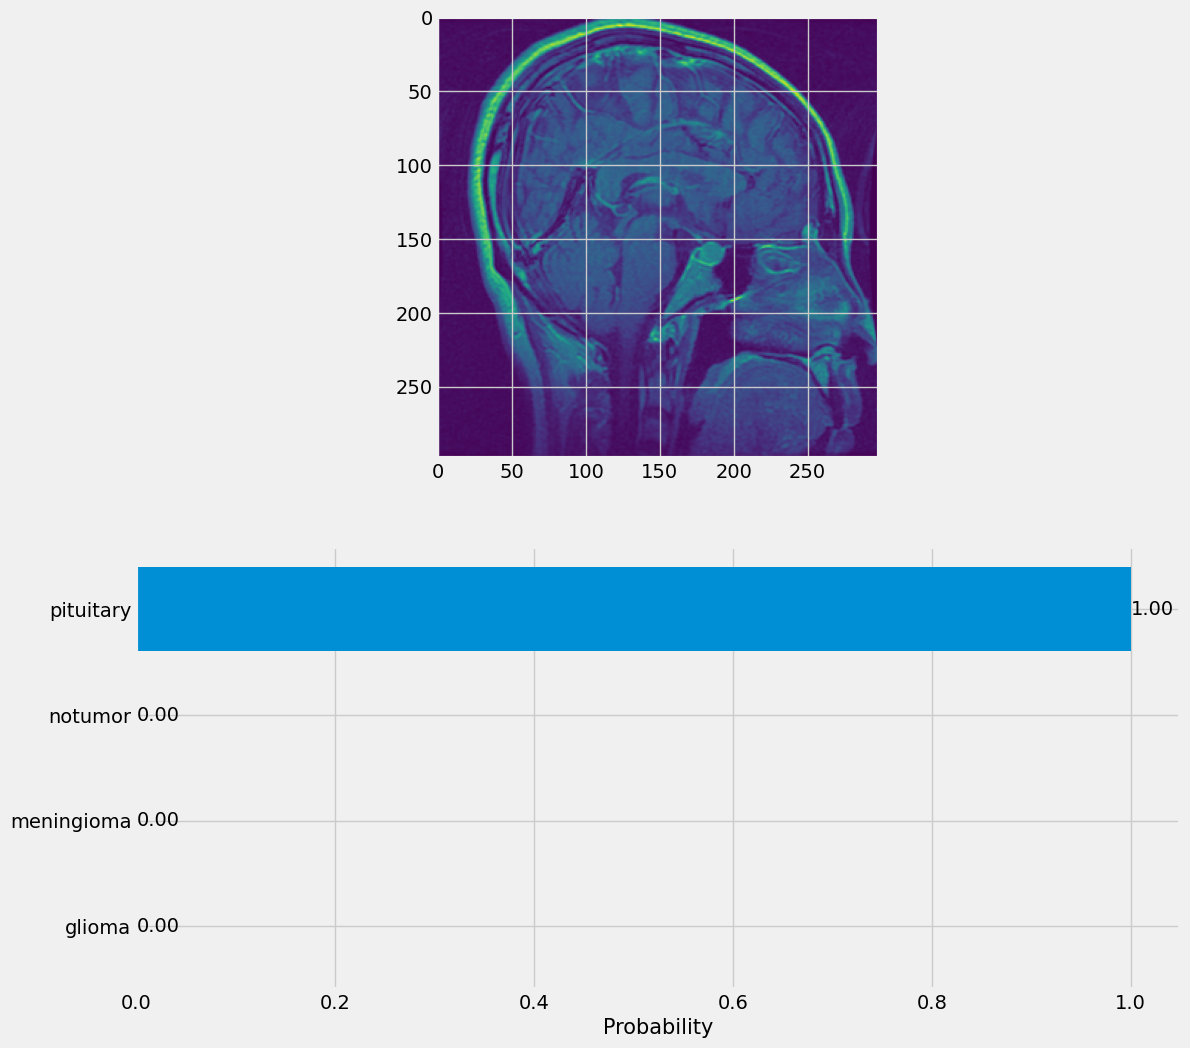

In [35]:
pituitary_image_path = ts_df[ts_df['Class'] == 'pituitary'].sample(1)['Class Path'].iloc[0]
predict(pituitary_image_path)